In [36]:
import pandas as pd
# просто проверяю, что все правильно считывается, вывожу первые 5 строк через head ()
df = pd.read_csv("донорство_резы.csv", encoding='utf-8', sep=',', skipinitialspace=True)
df = df.dropna(axis=1, how='all')
df.head()

,Пол,Возраст,1. Какие факторы мотивируют вас сдавать кровь?,2. Что для вас наиболее важно в процессе донорства?,3. Какие преимущества вы бы хотели получать как донор?,"4. Есть ли у вас какие-либо опасения или страхи, связанные с процессом сдачи крови?",5. Используете ли вы когда-либо приложения для доноров?,6. Какие функции мобильного приложения или веб-сайта для доноров вы бы хотели использовать?,7. Какой информацией вы бы хотели быть обеспечены перед сдачей крови?
0,Ж,19,"Желание помочь другим, Моральное удовлетворени...","Чистота и удобство помещения, Доступность инфо...","Бесплатные медицинские обследования, Приоритет...","Страх уколов, Страх перед возможными побочными...",Не знаю о таких приложениях,"Календарь донорских акций и мероприятий, Возмо...",Информация о процессе сдачи крови (как проходи...
1,Ж,25,"Признание в обществе, Получение наград или при...","Удобное местоположение пункта сдачи крови, Про...","Бесплатные медицинские обследования, Специальн...","Боязнь боли, Страх перед возможными побочными ...",Не знаю о таких приложениях,"Уведомления о потребности в моей группе крови,...","Пояснения о том, как моя кровь поможет пациент..."
2,Ж,21,"Желание помочь другим, Признание в обществе, П...","Удобное местоположение пункта сдачи крови, Про...","Награды за количество сдач (например, подарки,...","Страх уколов, Боязнь боли, Страх перед возможн...",Не знаю о таких приложениях,"Уведомления о потребности в моей группе крови,...",Детали о возможных побочных эффектах и их пред...
3,Ж,18,"Благодарность от медицинских учреждений, Получ...",Профессионализм и доброжелательность персонала...,"Мотивационные программы (например, баллы, кото...","Страх уколов, Боязнь боли","Нет, никогда","Уведомления о потребности в моей группе крови,...",Рекомендации по восстановлению после сдачи кро...
4,Ж,20,"Желание помочь другим, Признание в обществе",Профессионализм и доброжелательность персонала...,Возможность участвовать в просветительских акц...,"Страх уколов, Страх, что после сдачи крови буд...","Да, иногда","Отслеживание прогресса и достижений (например,...",Контактные данные для обратной связи с медицин...


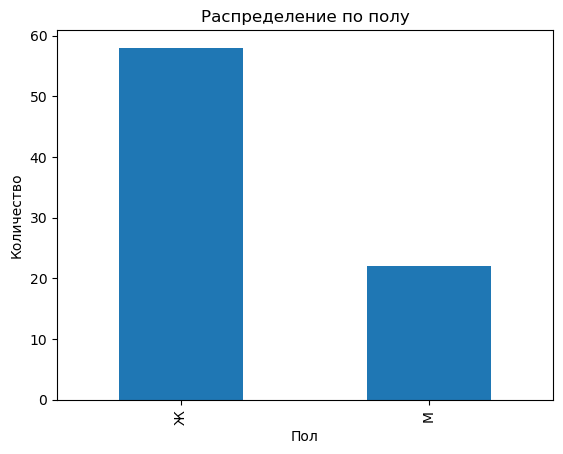

Женщины: 58
Мужчины: 22


In [37]:
import matplotlib.pyplot as plt
df['Пол'].value_counts().plot(kind='bar')
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.show()

gender_counts = df['Пол'].value_counts()
print("Женщины:", gender_counts.get('Ж', 0))
print("Мужчины:", gender_counts.get('М', 0))

Описательная статистика:
count    80.000000
mean     21.600000
std       2.281461
min      18.000000
25%      20.000000
50%      21.000000
75%      24.000000
max      25.000000
Name: Возраст, dtype: float64

Медиана:
21.0

Минимум: 18
Максимум: 25

Распределение возраста:
Возраст
18     7
19    12
20     9
21    14
22     8
23     7
24    12
25    11
Name: count, dtype: int64

Возрастные группы:
Возраст_группа
18–20    21
21–23    29
24–26    23
27–30     0
31–40     0
Name: count, dtype: int64

Возрастные группы (%):
Возраст_группа
18–20    28.8
21–23    39.7
24–26    31.5
27–30     0.0
31–40     0.0
Name: proportion, dtype: float64

Таблица:
  Возрастная группа  Количество
0             18–20          21
1             21–23          29
2             24–26          23
3             27–30           0
4             31–40           0


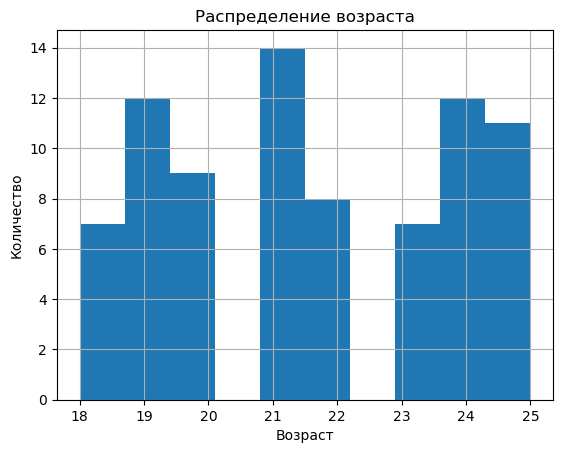

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# описательнеы статистики по базе
print("Описательная статистика:")
print(df['Возраст'].describe())
print("\nМедиана:")
print(df['Возраст'].median())
print("\nМинимум:", df['Возраст'].min())
print("Максимум:", df['Возраст'].max())
print("\nРаспределение возраста:")
print(df['Возраст'].value_counts().sort_index())

# группировка (чтобы не было много разрозненных точек)
bins = [18, 20, 23, 26, 30, 40]
labels = ['18–20', '21–23', '24–26', '27–30', '31–40']

df['Возраст_группа'] = pd.cut(df['Возраст'], bins=bins, labels=labels)

print("\nВозрастные группы:")
print(df['Возраст_группа'].value_counts().sort_index())
print("\nВозрастные группы (%):")
print((df['Возраст_группа'].value_counts(normalize=True).sort_index() * 100).round(1))

# табличка
age_table = df['Возраст_группа'].value_counts().sort_index().reset_index()
age_table.columns = ['Возрастная группа', 'Количество']

print("\nТаблица:")
print(age_table)

# график возраста
plt.figure()
df['Возраст'].hist()
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

ВОПРОС 1
                                               Ответ  Количество
0                              Желание помочь другим          53
1                               Признание в обществе          42
2                 Чувство социальной ответственности          20
3                           Моральное удовлетворение          19
4                    Получение наград или привилегий          17
5            Благодарность от медицинских учреждений          13
6  Личный опыт (например, спасение близкого челов...          11
7                                   Другое (указать)           5

ВОПРОС 2
                                                Ответ  Количество
0                        Процесс сдачи крови без боли          39
1       Информация о том, как моя кровь поможет людям          39
2      Профессионализм и доброжелательность персонала          38
3                          Минимальное время ожидания          17
4           Удобное местоположение пункта сдачи крови          16


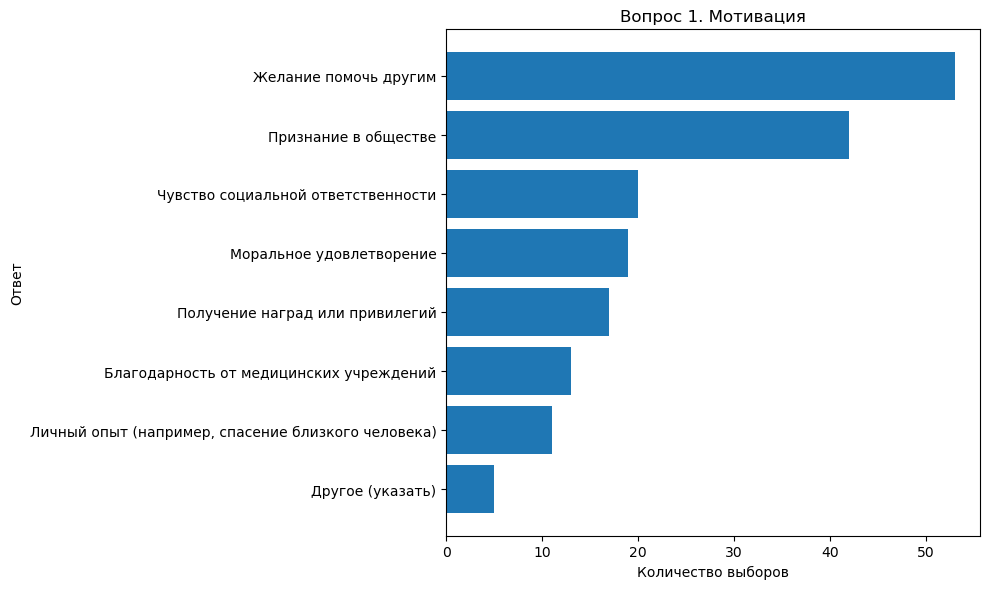

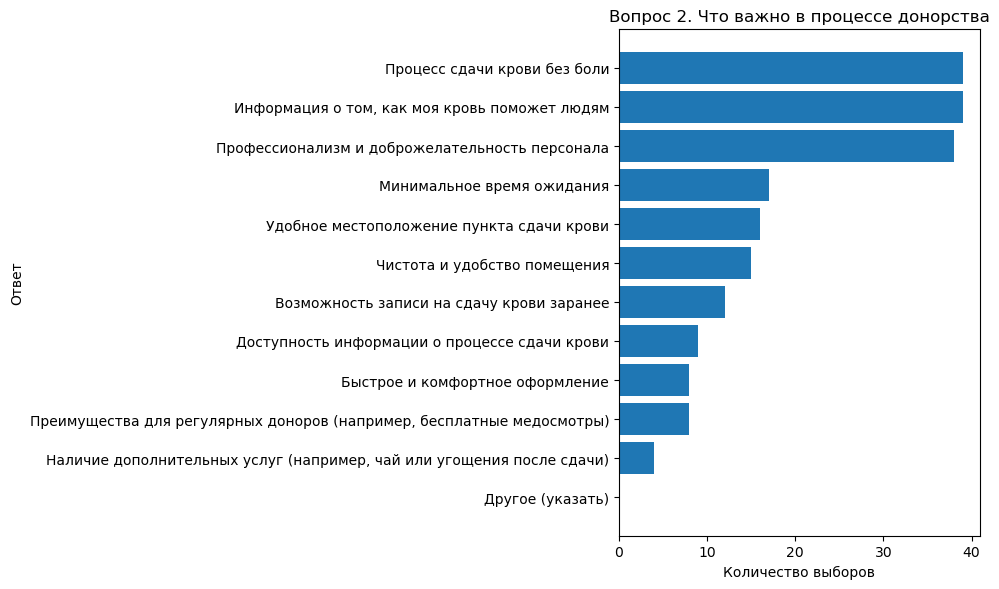

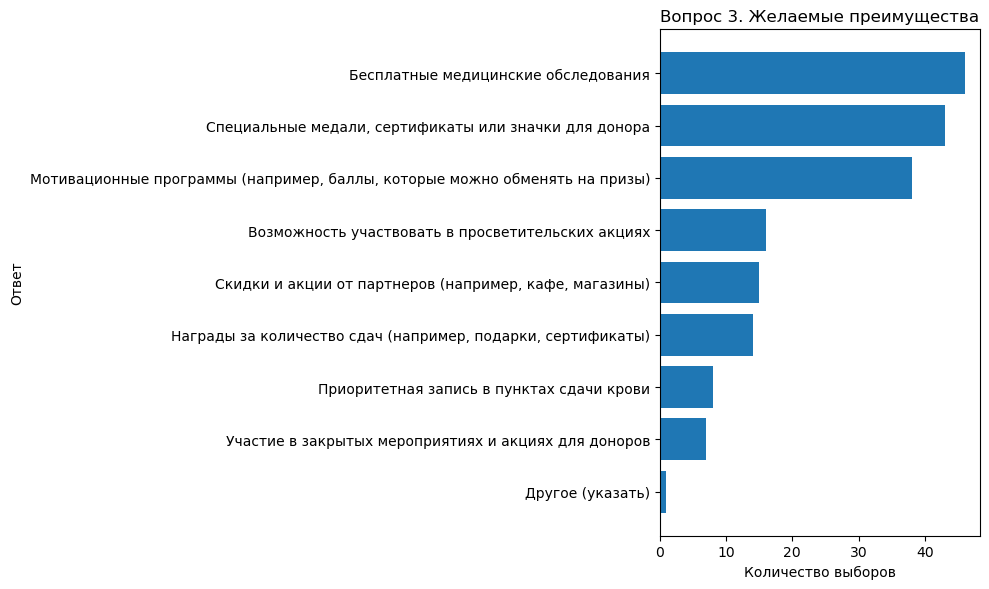

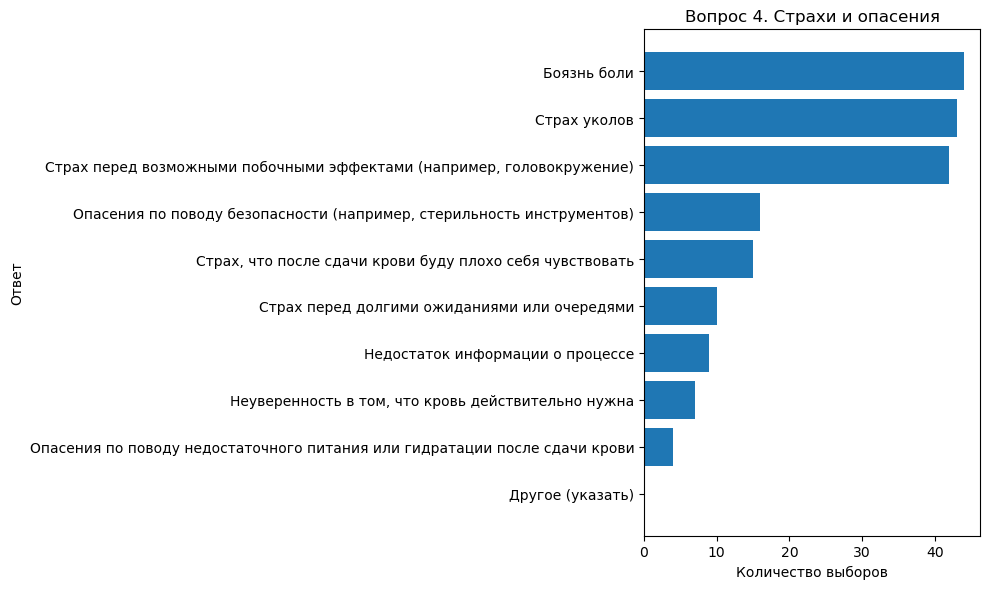

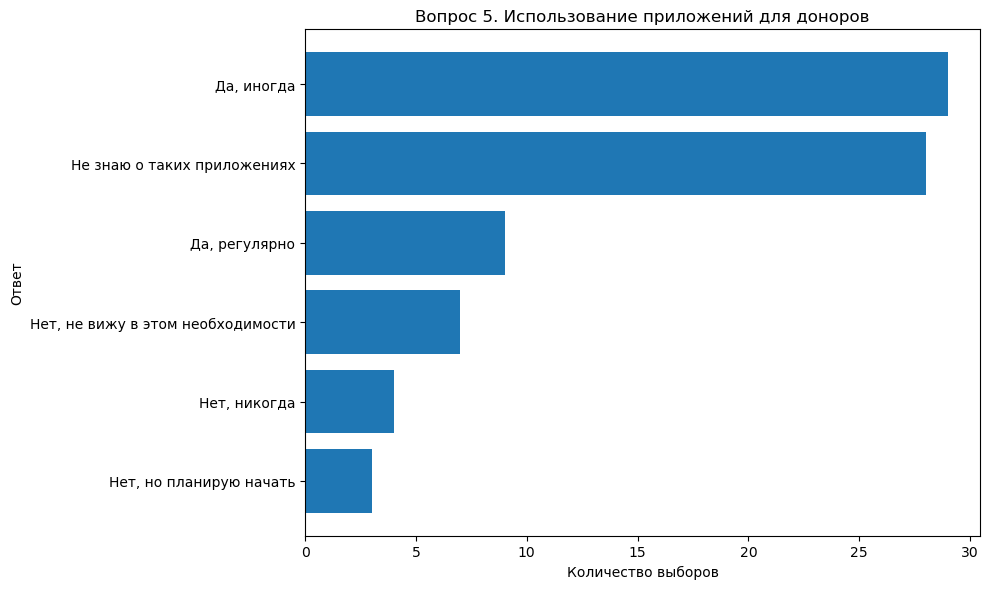

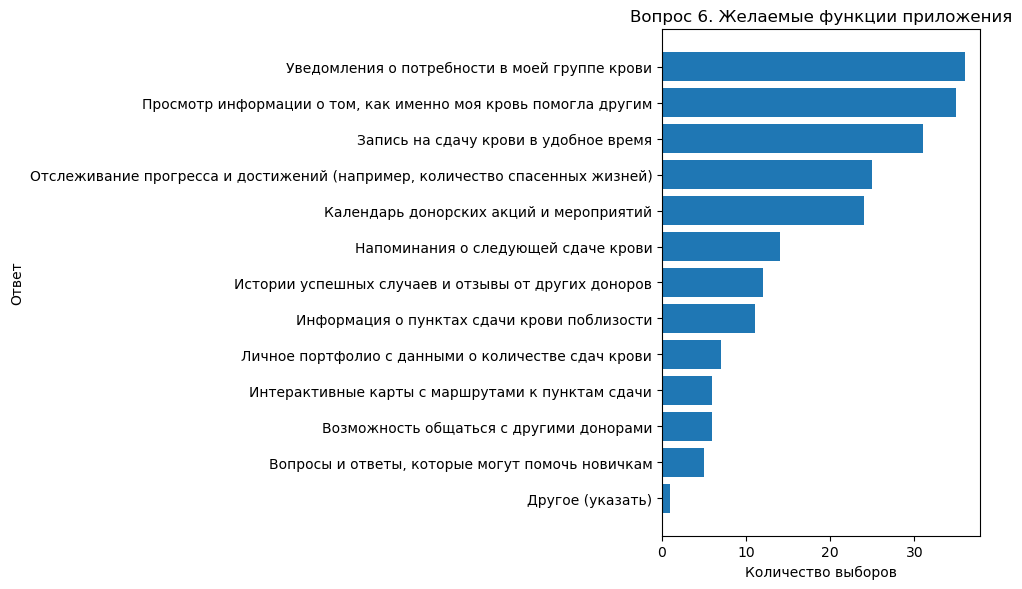

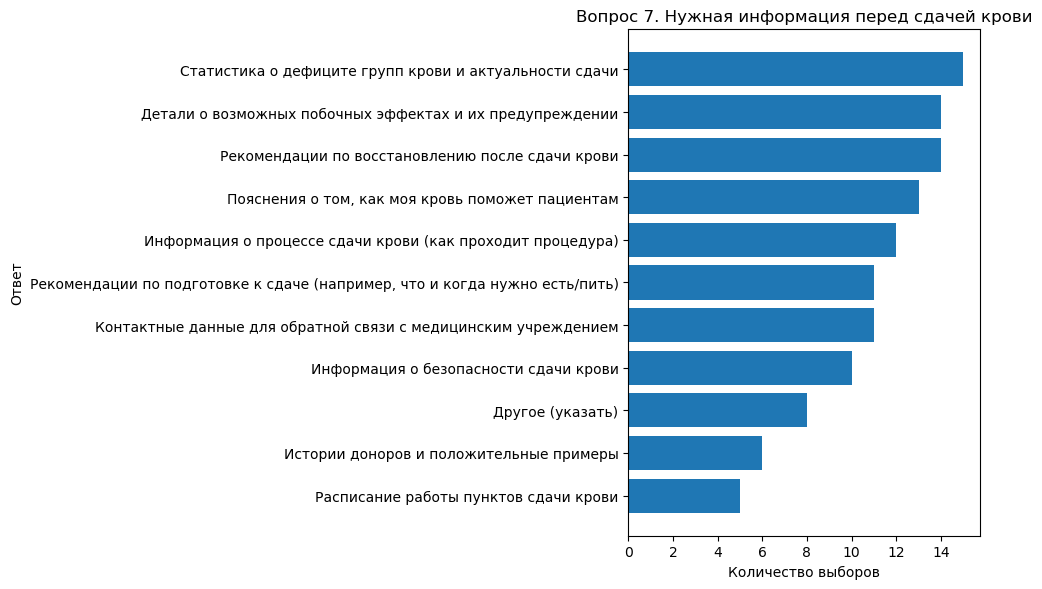

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# названия столбцов
q1 = '1. Какие факторы мотивируют вас сдавать кровь?'
q2 = '2. Что для вас наиболее важно в процессе донорства?'
q3 = '3. Какие преимущества вы бы хотели получать как донор?'
q4 = '4. Есть ли у вас какие-либо опасения или страхи, связанные с процессом сдачи крови?'
q5 = '5. Используете ли вы когда-либо приложения для доноров?'
q6 = '6. Какие функции мобильного приложения или веб-сайта для доноров вы бы хотели использовать?'
q7 = '7. Какой информацией вы бы хотели быть обеспечены перед сдачей крови?'

# допустимые варианты ответов
options = {
    q1: [
        'Желание помочь другим',
        'Моральное удовлетворение',
        'Признание в обществе',
        'Личный опыт (например, спасение близкого человека)',
        'Благодарность от медицинских учреждений',
        'Получение наград или привилегий',
        'Чувство социальной ответственности',
        'Другое (указать)'
    ],
    q2: [
        'Удобное местоположение пункта сдачи крови',
        'Быстрое и комфортное оформление',
        'Профессионализм и доброжелательность персонала',
        'Чистота и удобство помещения',
        'Процесс сдачи крови без боли',
        'Минимальное время ожидания',
        'Доступность информации о процессе сдачи крови',
        'Возможность записи на сдачу крови заранее',
        'Наличие дополнительных услуг (например, чай или угощения после сдачи)',
        'Информация о том, как моя кровь поможет людям',
        'Преимущества для регулярных доноров (например, бесплатные медосмотры)',
        'Другое (указать)'
    ],
    q3: [
        'Бесплатные медицинские обследования',
        'Награды за количество сдач (например, подарки, сертификаты)',
        'Скидки и акции от партнеров (например, кафе, магазины)',
        'Приоритетная запись в пунктах сдачи крови',
        'Участие в закрытых мероприятиях и акциях для доноров',
        'Мотивационные программы (например, баллы, которые можно обменять на призы)',
        'Возможность участвовать в просветительских акциях',
        'Специальные медали, сертификаты или значки для донора',
        'Другое (указать)'
    ],
    q4: [
        'Страх уколов',
        'Боязнь боли',
        'Страх перед возможными побочными эффектами (например, головокружение)',
        'Опасения по поводу безопасности (например, стерильность инструментов)',
        'Страх, что после сдачи крови буду плохо себя чувствовать',
        'Опасения по поводу недостаточного питания или гидратации после сдачи крови',
        'Недостаток информации о процессе',
        'Неуверенность в том, что кровь действительно нужна',
        'Страх перед долгими ожиданиями или очередями',
        'Другое (указать)'
    ],
    q5: [
        'Да, регулярно',
        'Да, иногда',
        'Нет, никогда',
        'Нет, но планирую начать',
        'Нет, не вижу в этом необходимости',
        'Не знаю о таких приложениях'
    ],
    q6: [
        'Запись на сдачу крови в удобное время',
        'Уведомления о потребности в моей группе крови',
        'Личное портфолио с данными о количестве сдач крови',
        'Отслеживание прогресса и достижений (например, количество спасенных жизней)',
        'Напоминания о следующей сдаче крови',
        'Календарь донорских акций и мероприятий',
        'Информация о пунктах сдачи крови поблизости',
        'Интерактивные карты с маршрутами к пунктам сдачи',
        'Просмотр информации о том, как именно моя кровь помогла другим',
        'Истории успешных случаев и отзывы от других доноров',
        'Вопросы и ответы, которые могут помочь новичкам',
        'Возможность общаться с другими донорами',
        'Другое (указать)'
    ],
    q7: [
        'Информация о процессе сдачи крови (как проходит процедура)',
        'Рекомендации по подготовке к сдаче (например, что и когда нужно есть/пить)',
        'Пояснения о том, как моя кровь поможет пациентам',
        'Информация о безопасности сдачи крови',
        'Детали о возможных побочных эффектах и их предупреждении',
        'Расписание работы пунктов сдачи крови',
        'Статистика о дефиците групп крови и актуальности сдачи',
        'Рекомендации по восстановлению после сдачи крови',
        'Истории доноров и положительные примеры',
        'Контактные данные для обратной связи с медицинским учреждением',
        'Другое (указать)'
    ]
}

# функция подсчета
def count_answers(column_name, allowed_options):
    counts = {option: 0 for option in allowed_options}

    for value in df[column_name].dropna():
        text = str(value).strip()
        for option in allowed_options:
            if option in text:
                counts[option] += 1

    result = pd.DataFrame({
        'Ответ': list(counts.keys()),
        'Количество': list(counts.values())
    })

    result = result.sort_values(by='Количество', ascending=False).reset_index(drop=True)
    return result

# функция графика
def plot_answers(table, title):
    plt.figure(figsize=(10, 6))
    plt.barh(table['Ответ'], table['Количество'])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel('Количество выборов')
    plt.ylabel('Ответ')
    plt.tight_layout()
    plt.show()

# обработка всех вопросов
table_q1 = count_answers(q1, options[q1])
table_q2 = count_answers(q2, options[q2])
table_q3 = count_answers(q3, options[q3])
table_q4 = count_answers(q4, options[q4])
table_q5 = count_answers(q5, options[q5])
table_q6 = count_answers(q6, options[q6])
table_q7 = count_answers(q7, options[q7])

# вывод таблиц
print('ВОПРОС 1')
print(table_q1)

print('\nВОПРОС 2')
print(table_q2)

print('\nВОПРОС 3')
print(table_q3)

print('\nВОПРОС 4')
print(table_q4)

print('\nВОПРОС 5')
print(table_q5)

print('\nВОПРОС 6')
print(table_q6)

print('\nВОПРОС 7')
print(table_q7)

# графики
plot_answers(table_q1, 'Вопрос 1. Мотивация')
plot_answers(table_q2, 'Вопрос 2. Что важно в процессе донорства')
plot_answers(table_q3, 'Вопрос 3. Желаемые преимущества')
plot_answers(table_q4, 'Вопрос 4. Страхи и опасения')
plot_answers(table_q5, 'Вопрос 5. Использование приложений для доноров')
plot_answers(table_q6, 'Вопрос 6. Желаемые функции приложения')
plot_answers(table_q7, 'Вопрос 7. Нужная информация перед сдачей крови')